In [1]:
import os
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [16]:
# ============================================================================
# 1. CONFIGURATION PARAMETERS
# ============================================================================

CONFIG = {
    "dataset_path": "/content/rgbd-dataset_eval_extracted/rgbd-dataset_eval/",
    "batch_size": 32,
    "num_workers": 4,
    "image_size": (224, 224),
    "train_split": 0.7,
    "val_split": 0.15,
    "test_split": 0.15,
    "random_seed": 42,
    # RGB Preprocessing
    "normalize_rgb": True,
    "rgb_mean": [0.485, 0.456, 0.406],
    "rgb_std": [0.229, 0.224, 0.225],
    # Depth Preprocessing
    "normalize_depth": True,
    "depth_max_value": 10000,
    "fill_missing_depth": "zero",
    "depth_bilateral_filter": True,
    "depth_filter_sigma": 1.0,
    # RGB-D Fusion
    "fusion_strategy": "concatenation",  # "concatenation", "separate"
    # Augmentation
    "augmentation": True,
    "rotation_range": 15,
    "scale_range": (0.9, 1.1),
    "horizontal_flip": True,
    "brightness_jitter": 0.2,
    "contrast_jitter": 0.2,
}

In [22]:
# ============================================================================
# 2. WASHINGTON RGB-D DATASET CLASS
# ============================================================================

class WashingtonRGBDDataset(Dataset):
    """
    Dataset loader for Washington RGB-D Object Dataset

    Directory structure expected:
    dataset_path/
    ├── object_01/
    │   ├── rgb_01_1_1_crop.png
    │   ├── crop_1_1_1_depthcrop.png
    │   ├── rgb_01_1_2_crop.png
    │   ├── crop_1_1_2_crop.png
    │   └── ...
    ├── object_02/
    └── ...
    """

    def __init__(self,
                 dataset_path,
                 image_size=(224, 224),
                 config=None,
                 transform=None,
                 split="train",
                 max_samples=15000):
        """
        Args:
            dataset_path: Path to Washington RGB-D dataset root
            image_size: Target image size (H, W)
            config: Configuration dictionary
            transform: Transforms to apply
            split: "train", "val", or "test"
            max_samples: Maximum number of samples to load (default: 15000)
        """
        self.dataset_path = Path(dataset_path)
        self.image_size = image_size
        self.config = config or CONFIG
        self.transform = transform
        self.split = split
        self.max_samples = max_samples

        # Collect all RGB-D pairs
        self.samples = []
        self.class_names = []
        self._load_dataset()

    def _load_dataset(self):
        """Load all RGB-D image pairs from dataset"""
        print(f"Debug: dataset_path: {self.dataset_path}")
        object_dirs = sorted([d for d in self.dataset_path.iterdir() if d.is_dir()])
        print(f"Debug: Found {len(object_dirs)} object directories.")

        class_idx = 0
        for obj_dir in object_dirs:
            class_name = obj_dir.name
            self.class_names.append(class_name)

            # Iterate through subdirectories within each object directory (e.g., apple_1, apple_2)
            view_dirs = sorted([d for d in obj_dir.iterdir() if d.is_dir()])
            print(f"Debug: In {obj_dir.name}, found {len(view_dirs)} view subdirectories.")

            for view_dir in view_dirs:
                # Find all RGB images in this view subdirectory
                # The pattern seems to be <object_name>_<view>_<illumination>_<rotation>_crop.png
                rgb_images = sorted(view_dir.glob("*_crop.png"))
                print(f"Debug: In {view_dir.name}, found {len(rgb_images)} RGB images.")

                for rgb_path in rgb_images:
                    # Stop if we've reached max samples
                    if len(self.samples) >= self.max_samples:
                        break

                    # Construct corresponding depth image path
                    # Example: apple_1_1_101_crop.png -> apple_1_1_101_depthcrop.png
                    rgb_name = rgb_path.stem  # "apple_1_1_101_crop"
                    depth_name = rgb_name.replace("_crop", "_depthcrop") + ".png"
                    depth_path = rgb_path.parent / depth_name

                    if depth_path.exists():
                        self.samples.append({
                            "rgb_path": str(rgb_path),
                            "depth_path": str(depth_path),
                            "label": class_idx,
                            "class_name": class_name
                        })

            class_idx += 1

            # Stop if we've reached max samples
            if len(self.samples) >= self.max_samples:
                break

        print(f"Loaded {len(self.samples)} RGB-D pairs from {len(self.class_names)} classes (max: {self.max_samples})")

    def _load_rgb(self, path):
        """Load RGB image"""
        rgb = cv2.imread(path)
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        return rgb

    def _load_depth(self, path):
        """Load depth image"""
        # Depth images are typically 16-bit PNG
        depth = cv2.imread(path, cv2.IMREAD_ANYDEPTH)
        return depth.astype(np.float32)

    def _preprocess_rgb(self, rgb):
        """Preprocess RGB image"""
        # Resize
        rgb = cv2.resize(rgb, self.image_size)

        # Convert to float
        rgb = rgb.astype(np.float32) / 255.0

        # Normalize using ImageNet statistics
        if self.config["normalize_rgb"]:
            rgb = (rgb - np.array(self.config["rgb_mean"])) / np.array(self.config["rgb_std"])

        return rgb

    def _preprocess_depth(self, depth):
        """Preprocess depth image"""
        # Resize
        depth = cv2.resize(depth, self.image_size)

        # Fill missing values (0 or NaN indicate invalid depth)
        if self.config["fill_missing_depth"] == "zero":
            depth[depth == 0] = 0
        elif self.config["fill_missing_depth"] == "interpolate":
            # Simple interpolation for missing values
            mask = depth == 0
            if np.any(mask):
                depth = cv2.inpaint(depth.astype(np.uint8), mask.astype(np.uint8), 3, cv2.INPAINT_TELEA)
                depth = depth.astype(np.float32)

        # Apply bilateral filter for denoising
        if self.config["depth_bilateral_filter"]:
            depth = cv2.bilateralFilter(depth, 9, 75, 75)

        # Normalize depth
        if self.config["normalize_depth"]:
            depth = np.clip(depth, 0, self.config["depth_max_value"])
            depth = depth / self.config["depth_max_value"]

        return depth

    def _augment_data(self, rgb, depth):
        """Apply data augmentation"""
        if not self.config["augmentation"] or self.split == "test":
            return rgb, depth

        h, w = rgb.shape[:2]

        # Random rotation
        if self.config["rotation_range"] > 0:
            angle = np.random.uniform(-self.config["rotation_range"],
                                      self.config["rotation_range"])
            matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
            rgb = cv2.warpAffine(rgb, matrix, (w, h))
            depth = cv2.warpAffine(depth, matrix, (w, h))

        # Random scaling
        scale = np.random.uniform(self.config["scale_range"][0],
                                  self.config["scale_range"][1])
        new_w, new_h = int(w * scale), int(h * scale)
        rgb = cv2.resize(rgb, (new_w, new_h))
        depth = cv2.resize(depth, (new_w, new_h))

        # Pad back to original size if smaller
        if new_h < h or new_w < w:
            rgb = cv2.copyMakeBorder(rgb, 0, h - new_h, 0, w - new_w,
                                     cv2.BORDER_REFLECT)
            depth = cv2.copyMakeBorder(depth, 0, h - new_h, 0, w - new_w,
                                       cv2.BORDER_REFLECT)
        # Crop if larger
        else:
            start_h, start_w = (new_h - h) // 2, (new_w - w) // 2
            rgb = rgb[start_h:start_h+h, start_w:start_w+w]
            depth = depth[start_h:start_h+h, start_w:start_w+w]

        # Random horizontal flip
        if self.config["horizontal_flip"] and np.random.rand() > 0.5:
            rgb = cv2.flip(rgb, 1)
            depth = cv2.flip(depth, 1)

        # Brightness jitter (RGB only)
        if self.config["brightness_jitter"] > 0 and self.split == "train":
            brightness_factor = 1 + np.random.uniform(-self.config["brightness_jitter"],
                                                      self.config["brightness_jitter"])
            rgb = np.clip(rgb * brightness_factor, 0, 1)

        # Contrast jitter (RGB only)
        if self.config["contrast_jitter"] > 0 and self.split == "train":
            contrast_factor = 1 + np.random.uniform(-self.config["contrast_jitter"],
                                                    self.config["contrast_jitter"])
            rgb_mean = rgb.mean()
            rgb = np.clip((rgb - rgb_mean) * contrast_factor + rgb_mean, 0, 1)

        return rgb, depth

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load RGB and depth
        rgb = self._load_rgb(sample["rgb_path"])
        depth = self._load_depth(sample["depth_path"])

        # Preprocess
        rgb = self._preprocess_rgb(rgb)
        depth = self._preprocess_depth(depth)

        # Augment
        rgb, depth = self._augment_data(rgb, depth)

        # Fusion: Concatenate RGB and depth channels
        if self.config["fusion_strategy"] == "concatenation":
            # Add channel dimension to depth if needed
            if len(depth.shape) == 2:
                depth = np.expand_dims(depth, axis=2)
            # Concatenate: [R, G, B, D]
            rgbd = np.concatenate([rgb, depth], axis=2)
            data = torch.from_numpy(rgbd).permute(2, 0, 1).float()
        else:  # separate
            rgb_tensor = torch.from_numpy(rgb).permute(2, 0, 1).float()
            depth_tensor = torch.from_numpy(np.expand_dims(depth, axis=2)).permute(2, 0, 1).float()
            data = (rgb_tensor, depth_tensor)

        label = torch.tensor(sample["label"], dtype=torch.long)

        return data, label, sample["class_name"]

In [4]:
# ============================================================================
# 3. DATA LOADING FUNCTION
# ============================================================================

def create_data_loaders(config):
    """Create train, val, and test data loaders"""

    # Create full dataset
    full_dataset = WashingtonRGBDDataset(
        config["dataset_path"],
        image_size=config["image_size"],
        config=config,
        split="train"
    )

    # Split indices
    train_indices, temp_indices = train_test_split(
        range(len(full_dataset)),
        test_size=config["val_split"] + config["test_split"],
        random_state=config["random_seed"]
    )

    val_size = len(temp_indices) // 2
    val_indices = temp_indices[:val_size]
    test_indices = temp_indices[val_size:]

    # Create subset datasets
    from torch.utils.data import Subset

    train_dataset = Subset(full_dataset, train_indices)
    val_dataset = Subset(full_dataset, val_indices)
    test_dataset = Subset(full_dataset, test_indices)

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=True
    )

    print(f"\nData split:")
    print(f"  Train: {len(train_dataset)} samples")
    print(f"  Val:   {len(val_dataset)} samples")
    print(f"  Test:  {len(test_dataset)} samples")

    return train_loader, val_loader, test_loader, full_dataset

In [5]:
# ============================================================================
# 4. VISUALIZATION FUNCTION
# ============================================================================

def visualize_rgbd_samples(data_loader, num_samples=4):
    """Visualize RGB-D samples from the dataset"""

    batch_data, batch_labels, batch_class_names = next(iter(data_loader))

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 10))

    for i in range(min(num_samples, len(batch_data))):
        # Extract RGBD
        rgbd = batch_data[i].numpy().transpose(1, 2, 0)  # (H, W, 4)

        # Split into RGB and depth
        rgb = rgbd[:, :, :3]
        depth = rgbd[:, :, 3]

        # Denormalize RGB for visualization
        rgb = (rgb * np.array(CONFIG["rgb_std"]) + np.array(CONFIG["rgb_mean"]))
        rgb = np.clip(rgb, 0, 1)

        # Visualize RGB
        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title(f"{batch_class_names[i]} - RGB")
        axes[i, 0].axis("off")

        # Visualize Depth
        axes[i, 1].imshow(depth, cmap="viridis")
        axes[i, 1].set_title(f"{batch_class_names[i]} - Depth")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.savefig("rgbd_samples.png", dpi=150, bbox_inches="tight")
    print("Saved visualization to rgbd_samples.png")
    plt.show()

Washington RGB-D Dataset Preprocessing Pipeline
Debug: dataset_path: /content/rgbd-dataset_eval_extracted/rgbd-dataset_eval
Debug: Found 51 object directories.
Debug: In apple, found 5 view subdirectories.
Debug: In apple_1, found 122 RGB images.
Debug: In apple_2, found 126 RGB images.
Debug: In apple_3, found 123 RGB images.
Debug: In apple_4, found 127 RGB images.
Debug: In apple_5, found 127 RGB images.
Debug: In ball, found 7 view subdirectories.
Debug: In ball_1, found 165 RGB images.
Debug: In ball_2, found 158 RGB images.
Debug: In ball_3, found 163 RGB images.
Debug: In ball_4, found 162 RGB images.
Debug: In ball_5, found 160 RGB images.
Debug: In ball_6, found 159 RGB images.
Debug: In ball_7, found 154 RGB images.
Debug: In banana, found 4 view subdirectories.
Debug: In banana_1, found 146 RGB images.
Debug: In banana_2, found 144 RGB images.
Debug: In banana_3, found 141 RGB images.
Debug: In banana_4, found 138 RGB images.
Debug: In bell_pepper, found 6 view subdirectorie

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

Batch shape: torch.Size([32, 4, 224, 224])
Batch labels: tensor([ 9, 15, 14, 16, 17])
Sample class names: ('cell_phone', 'food_bag', 'flashlight', 'food_box', 'food_can')

Visualizing samples...
Saved visualization to rgbd_samples.png


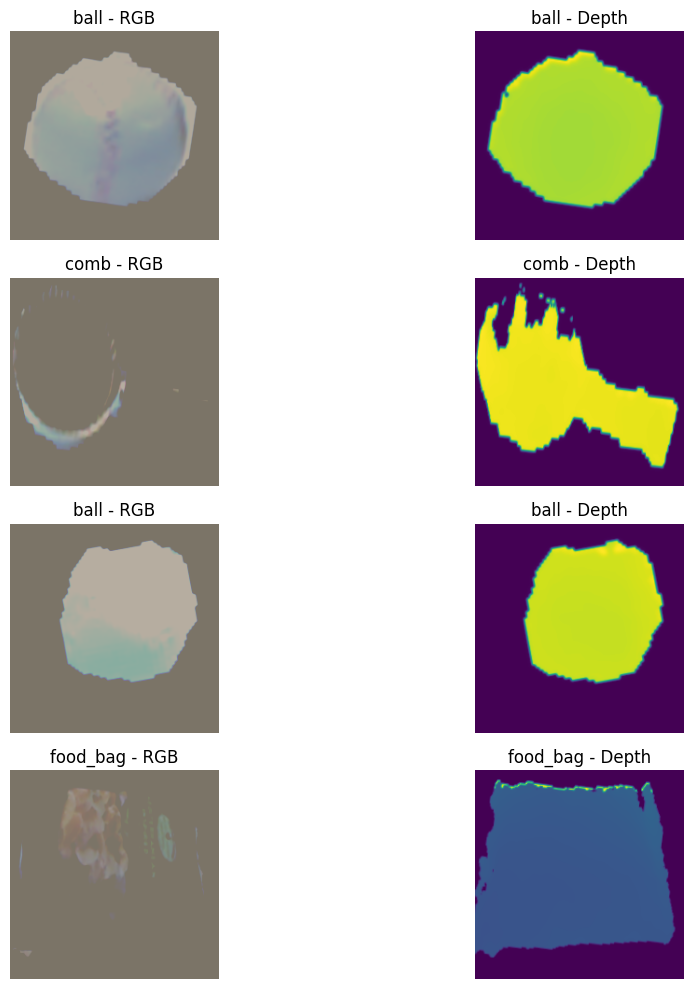


Preprocessing complete! Data loaders ready for training.


In [23]:
# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":

    print("=" * 70)
    print("Washington RGB-D Dataset Preprocessing Pipeline")
    print("=" * 70)

    # Set random seed for reproducibility
    np.random.seed(CONFIG["random_seed"])
    torch.manual_seed(CONFIG["random_seed"])

    # Create data loaders
    train_loader, val_loader, test_loader, full_dataset = create_data_loaders(CONFIG)

    print(f"\nNumber of classes: {len(full_dataset.class_names)}")
    print(f"Classes: {full_dataset.class_names[:5]}... (showing first 5)")

    # Get a sample batch
    print("\nLoading sample batch...")
    batch_data, batch_labels, batch_class_names = next(iter(train_loader))

    print(f"Batch shape: {batch_data.shape}")
    print(f"Batch labels: {batch_labels[:5]}")
    print(f"Sample class names: {batch_class_names[:5]}")

    # Visualize samples
    print("\nVisualizing samples...")
    visualize_rgbd_samples(train_loader, num_samples=4)

    print("\n" + "=" * 70)
    print("Preprocessing complete! Data loaders ready for training.")
    print("=" * 70)

In [21]:
# Debugging the file structure to understand why no RGB images are found.
!ls -R /content/rgbd-dataset_eval_extracted/rgbd-dataset_eval/apple/

/content/rgbd-dataset_eval_extracted/rgbd-dataset_eval/apple/:
apple_1  apple_2  apple_3  apple_4  apple_5

/content/rgbd-dataset_eval_extracted/rgbd-dataset_eval/apple/apple_1:
apple_1_1_101_crop.png	     apple_1_2_186_crop.png
apple_1_1_101_depthcrop.png  apple_1_2_186_depthcrop.png
apple_1_1_101_loc.txt	     apple_1_2_186_loc.txt
apple_1_1_101_maskcrop.png   apple_1_2_186_maskcrop.png
apple_1_1_106_crop.png	     apple_1_2_191_crop.png
apple_1_1_106_depthcrop.png  apple_1_2_191_depthcrop.png
apple_1_1_106_loc.txt	     apple_1_2_191_loc.txt
apple_1_1_106_maskcrop.png   apple_1_2_191_maskcrop.png
apple_1_1_111_crop.png	     apple_1_2_196_crop.png
apple_1_1_111_depthcrop.png  apple_1_2_196_depthcrop.png
apple_1_1_111_loc.txt	     apple_1_2_196_loc.txt
apple_1_1_111_maskcrop.png   apple_1_2_196_maskcrop.png
apple_1_1_116_crop.png	     apple_1_2_1_crop.png
apple_1_1_116_depthcrop.png  apple_1_2_1_depthcrop.png
apple_1_1_116_loc.txt	     apple_1_2_1_loc.txt
apple_1_1_116_maskcrop.png   app

In [14]:
!ls -F /content/rgbd-dataset_eval_extracted/

rgbd-dataset_eval/


In [10]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Define the path to your zipped dataset
zip_file_path = '/content/drive/MyDrive/GWU_AI_Capstone_Project/rgbd-dataset_eval.zip'

# Define the directory where you want to extract the dataset
extraction_path = '/content/rgbd-dataset_eval_extracted/' # You can change this path

# Create the extraction directory if it doesn't exist
!mkdir -p "{extraction_path}"

# Unzip the file. The -qq option makes it quiet.
!unzip -qq "{zip_file_path}" -d "{extraction_path}"

print(f"Dataset unzipped to: {extraction_path}")
print("Please update the 'dataset_path' in the CONFIG dictionary to this new extraction path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset unzipped to: /content/rgbd-dataset_eval_extracted/
Please update the 'dataset_path' in the CONFIG dictionary to this new extraction path.
